In [7]:
import pandas as pd
import urllib.request
import yfinance as yf

In [8]:
# ── Step 1: fetch S&P 500 list from iShares IVV (updated daily) ────────────
import requests
from io import StringIO

# ── Step 1: fetch S&P 500 list from Wikipedia using requests ───────────────
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

session = requests.Session()
session.headers.update({
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.5",
})

response = session.get(url)
print(f"Status code: {response.status_code}")

sp500 = pd.read_html(StringIO(response.text))[0]
sp500["Symbol"] = sp500["Symbol"].str.replace(".", "-", regex=False)
sp500 = sp500.reset_index(drop=True)

print(f"Total tickers: {len(sp500)}")
print(sp500["GICS Sector"].value_counts())
print(sp500[["Symbol", "GICS Sector"]].head(10))

Status code: 200
Total tickers: 503
GICS Sector
Industrials               81
Financials                76
Information Technology    74
Health Care               59
Consumer Discretionary    47
Consumer Staples          34
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    21
Name: count, dtype: int64
  Symbol             GICS Sector
0    MMM             Industrials
1    AOS             Industrials
2    ABT             Health Care
3   ABBV             Health Care
4    ACN  Information Technology
5   ADBE  Information Technology
6    AMD  Information Technology
7    AES               Utilities
8    AFL              Financials
9      A             Health Care


In [9]:
# ── Step 2: how many stocks to pick per sector ─────────────────────────────
sector_targets = {
    "Information Technology": 12,
    "Health Care":            10,
    "Financials":             10,
    "Consumer Discretionary":  8,
    "Industrials":             8,
    "Communication Services":  7,
    "Consumer Staples":        7,
    "Energy":                  6,
    "Utilities":               5,
    "Real Estate":             4,
    "Materials":               3,
}  # sums to 80

In [10]:
test = yf.download("AAPL", start="2015-01-01", end="2024-12-31",
                   auto_adjust=True, progress=False)
print("Columns:", test.columns.tolist())
print("Shape:", test.shape)
print(test.head(2))

Columns: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]
Shape: (2515, 5)
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.192602  24.659504  23.754466  24.648440  212818400
2015-01-05  23.511063  24.042136  23.325188  23.962475  257142000


In [11]:
# ── Step 3: get average volume for every S&P 500 ticker ───────────────────
# This takes ~10-15 minutes. Runs once, then we screen from the results.

def get_avg_volume(ticker, start="2015-01-01", end="2024-12-31", min_trading_days=2000):
    """
    Returns average daily volume if ticker passes screening, else None.
    Screens for: sufficient history, liquidity, data quality.
    """
    try:
        df = yf.download(ticker, start=start, end=end,
                         auto_adjust=True, progress=False)

        if df is None or df.empty:
            return None

        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        if len(df) < min_trading_days:
            return None
        if df["Close"].isnull().mean() > 0.01:
            return None

        avg_vol = float(df["Volume"].mean())
        if avg_vol < 500_000:
            return None

        return avg_vol

    except Exception as e:
        print(f"  ERROR {ticker}: {e}")
        return None

In [12]:
# ── Step 4: pick top-N by volume per sector ────────────────────────────────
print("\nFetching volume data... (~10-15 mins)\n")

volume_data = []
total = len(sp500)

for i in range(total):
    ticker = sp500.loc[i, "Symbol"]
    sector = sp500.loc[i, "GICS Sector"]
    avg_vol = get_avg_volume(ticker)

    status = f"{avg_vol:,.0f}" if avg_vol is not None else "FAILED"
    print(f"[{i+1:3d}/{total}] {ticker:<10} {sector:<35} {status}")

    volume_data.append({
        "ticker": ticker,
        "sector": sector,
        "avg_volume": avg_vol
    })



Fetching volume data... (~10-15 mins)

[  1/503] MMM        Industrials                         3,554,169
[  2/503] AOS        Industrials                         1,248,308
[  3/503] ABT        Health Care                         6,133,019
[  4/503] ABBV       Health Care                         7,325,530
[  5/503] ACN        Information Technology              2,284,802
[  6/503] ADBE       Information Technology              2,945,269
[  7/503] AMD        Information Technology              57,930,142
[  8/503] AES        Utilities                           6,180,263
[  9/503] AFL        Financials                          3,350,498
[ 10/503] A          Health Care                         1,998,473
[ 11/503] APD        Materials                           1,223,680
[ 12/503] ABNB       Consumer Discretionary              FAILED
[ 13/503] AKAM       Information Technology              1,775,267
[ 14/503] ALB        Materials                           1,638,077
[ 15/503] ARE        Rea


1 Failed download:
['FDXF']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-01-01 -> 2024-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1420088400, endDate = 1735621200")')


[196/503] FDXF       Industrials                         FAILED
[197/503] FIS        Financials                          3,117,605
[198/503] FITB       Financials                          6,230,432
[199/503] FSLR       Information Technology              2,232,469
[200/503] FE         Utilities                           4,131,636
[201/503] FISV       Financials                          3,083,329
[202/503] FLEX       Information Technology              5,829,422
[203/503] F          Consumer Discretionary              52,362,147
[204/503] FTNT       Information Technology              7,721,790
[205/503] FTV        Industrials                         3,105,828
[206/503] FOXA       Communication Services              FAILED
[207/503] FOX        Communication Services              FAILED
[208/503] BEN        Financials                          3,261,974
[209/503] FCX        Materials                           21,900,401
[210/503] GRMN       Consumer Discretionary              1,037,201
[2


1 Failed download:
['HONA']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-01-01 -> 2024-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1420088400, endDate = 1735621200")')


[236/503] HONA       Industrials                         FAILED
[237/503] HON        Industrials                         3,259,324
[238/503] HRL        Consumer Staples                    2,392,155
[239/503] HST        Real Estate                         8,014,783
[240/503] HWM        Industrials                         3,880,995
[241/503] HPQ        Information Technology              12,110,739
[242/503] HUBB       Industrials                         FAILED
[243/503] HUM        Health Care                         1,216,764
[244/503] HBAN       Financials                          12,365,401
[245/503] HII        Industrials                         FAILED
[246/503] IBM        Information Technology              4,797,254
[247/503] IEX        Industrials                         FAILED
[248/503] IDXX       Health Care                         552,236
[249/503] ITW        Industrials                         1,299,597
[250/503] INCY       Health Care                         1,659,205
[251/50


1 Failed download:
['Q']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-01-01 -> 2024-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1420088400, endDate = 1735621200")')


[386/503] Q          Information Technology              FAILED
[387/503] RL         Consumer Discretionary              1,096,514
[388/503] RJF        Financials                          1,232,329
[389/503] RTX        Industrials                         6,626,761
[390/503] O          Real Estate                         3,135,509
[391/503] REG        Real Estate                         987,160
[392/503] REGN       Health Care                         798,467
[393/503] RF         Financials                          12,042,360
[394/503] RSG        Industrials                         1,283,546
[395/503] RMD        Health Care                         798,097
[396/503] RVTY       Health Care                         768,939
[397/503] HOOD       Financials                          FAILED
[398/503] ROK        Industrials                         883,168
[399/503] ROL        Industrials                         1,531,562
[400/503] ROP        Information Technology              FAILED
[401/503] ROS


1 Failed download:
['SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-01-01 -> 2024-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1420088400, endDate = 1735621200")')


[405/503] SNDK       Information Technology              FAILED
[406/503] SBAC       Real Estate                         865,262
[407/503] SLB        Energy                              10,515,026
[408/503] STX        Information Technology              3,516,489
[409/503] SRE        Utilities                           2,980,224
[410/503] NOW        Information Technology              8,242,346
[411/503] SHW        Materials                           1,814,425
[412/503] SPG        Real Estate                         2,137,458
[413/503] SWKS       Information Technology              2,368,468
[414/503] SJM        Consumer Staples                    1,008,929
[415/503] SW         Materials                           FAILED
[416/503] SNA        Industrials                         FAILED
[417/503] SOLV       Health Care                         FAILED
[418/503] SO         Utilities                           4,861,479
[419/503] LUV        Industrials                         7,300,843
[420/503

In [13]:
# ── Step 5: build dataframe ────────────────────────────────────────────────
vol_df = pd.DataFrame(volume_data)
passed = vol_df.dropna(subset=["avg_volume"])
print(f"\n✓ {len(passed)} tickers passed out of {total}")
print(passed["sector"].value_counts())



✓ 440 tickers passed out of 503
sector
Financials                69
Industrials               62
Information Technology    62
Health Care               52
Consumer Discretionary    42
Consumer Staples          32
Utilities                 30
Real Estate               28
Materials                 23
Communication Services    21
Energy                    19
Name: count, dtype: int64


In [14]:
# ── Step 6: pick top-N by volume per sector ────────────────────────────────
selected = []
print("\n" + "=" * 60)
print(f"{'FINAL SELECTION':^60}")
print("=" * 60)

for sector, target_n in sector_targets.items():
    sector_df = passed[passed["sector"] == sector].sort_values(
        "avg_volume", ascending=False
    )
    picked = sector_df.head(target_n)

    print(f"\n{sector} — {len(picked)}/{target_n} picked")
    print(f"  {'Ticker':<12} {'Avg Daily Volume':>20}")
    print(f"  {'-'*12} {'-'*20}")
    for _, r in picked.iterrows():
        print(f"  {r['ticker']:<12} {r['avg_volume']:>20,.0f}")

    selected.append(picked)

selected_df = pd.concat(selected).reset_index(drop=True)


                      FINAL SELECTION                       

Information Technology — 12/12 picked
  Ticker           Avg Daily Volume
  ------------ --------------------
  NVDA                  467,755,662
  AAPL                  117,116,177
  AMD                    57,930,142
  INTC                   33,110,233
  MSFT                   28,885,595
  AVGO                   28,345,113
  MU                     25,346,386
  CSCO                   22,081,205
  LRCX                   19,407,299
  SMCI                   14,406,509
  KLAC                   13,727,187
  HPE                    13,121,233

Health Care — 10/10 picked
  Ticker           Avg Daily Volume
  ------------ --------------------
  PFE                    29,001,401
  BMY                    10,863,425
  MRK                    10,600,807
  GILD                    8,755,684
  BSX                     8,177,313
  JNJ                     7,721,086
  VTRS                    7,687,591
  CVS                     7,660,981
  ABBV 

In [15]:
# ── Step 7: final output ───────────────────────────────────────────────────
print("\n" + "=" * 60)
print(f"TOTAL SELECTED: {len(selected_df)} stocks")
print("=" * 60)

final_tickers = selected_df["ticker"].tolist()
print(f"\nCopy this into config.py as SP500_EQUITIES:")
print(final_tickers)


TOTAL SELECTED: 80 stocks

Copy this into config.py as SP500_EQUITIES:
['NVDA', 'AAPL', 'AMD', 'INTC', 'MSFT', 'AVGO', 'MU', 'CSCO', 'LRCX', 'SMCI', 'KLAC', 'HPE', 'PFE', 'BMY', 'MRK', 'GILD', 'BSX', 'JNJ', 'VTRS', 'CVS', 'ABBV', 'ABT', 'BAC', 'WFC', 'C', 'JPM', 'HBAN', 'RF', 'KEY', 'PYPL', 'XYZ', 'MS', 'TSLA', 'AMZN', 'F', 'CMG', 'CCL', 'GM', 'NCLH', 'BKNG', 'CSX', 'GE', 'DAL', 'UAL', 'FAST', 'BA', 'LUV', 'RTX', 'NFLX', 'T', 'GOOGL', 'GOOG', 'META', 'CMCSA', 'VZ', 'WMT', 'KO', 'MO', 'KR', 'PG', 'MDLZ', 'KHC', 'XOM', 'KMI', 'OXY', 'HAL', 'SLB', 'CVX', 'PCG', 'NEE', 'EXC', 'AES', 'PPL', 'HST', 'KIM', 'WY', 'DOC', 'FCX', 'NEM', 'MOS']


In [16]:
#Test compute_reutn.py function
from fetch_universe import fetch_prices
from compute_return import compute_all  # matches your filename

# load cached prices — no re-download
prices = fetch_prices()
ret, mu, Sigma = compute_all(prices)

print(f"Returns shape:       {ret.shape}")
print(f"Mu shape:            {mu.shape}")
print(f"Sigma shape:         {Sigma.shape}")

print(f"\nTop 5 by expected return:")
print(mu.nlargest(5).apply(lambda x: f"{x:.2%}"))

print(f"\nBottom 5 by expected return:")
print(mu.nsmallest(5).apply(lambda x: f"{x:.2%}"))

print(f"\nMost volatile assets:")
vol = pd.Series(np.sqrt(np.diag(Sigma.values)), index=Sigma.columns)
print(vol.nlargest(5).apply(lambda x: f"{x:.2%}"))

print(f"\nAny NaNs in returns? {ret.isnull().any().any()}")
print(f"Any NaNs in mu?      {mu.isnull().any()}")
print(f"Any NaNs in Sigma?   {Sigma.isnull().any().any()}")

Loading prices from cache...
Loaded 100 assets, 1866 days from cache
Returns shape:       (1865, 100)
Mu shape:            (100,)
Sigma shape:         (100, 100)

Top 5 by expected return:
SOL-USD    69.82%
BNB-USD    52.11%
SMCI       41.04%
NVDA       40.94%
ETH-USD    37.43%
dtype: object

Bottom 5 by expected return:
INTC    -11.65%
TLT      -6.98%
VTRS     -5.98%
PYPL     -5.15%
DOC      -2.78%
dtype: object

Most volatile assets:
SOL-USD    105.39%
BNB-USD     68.92%
ETH-USD     66.20%
SMCI        65.02%
NCLH        56.62%
dtype: object

Any NaNs in returns? False
Any NaNs in mu?      False
Any NaNs in Sigma?   False


In [17]:
#Test compute_cvar.py
from compute_cvar import cvar, expected_return

# use prices and ret already loaded from previous cell
scenarios = ret.values  # convert DataFrame to numpy array
M = scenarios.shape[1]

# Test 1: equal-weight portfolio
w_eq = np.ones(M) / M
print("=== Equal-weight portfolio ===")
print(f"CVaR95:     {cvar(w_eq, scenarios):.4f}  (expected loss in worst 5% of days)")
print(f"E[return]:  {expected_return(w_eq, mu.values):.4f}  (annualised)")

# Test 2: 100% in NVDA (highest return, should have very high CVaR)
w_nvda = np.zeros(M)
nvda_idx = list(prices.columns).index("NVDA")
w_nvda[nvda_idx] = 1.0
print("\n=== 100% NVDA ===")
print(f"CVaR95:     {cvar(w_nvda, scenarios):.4f}  (should be much higher than equal-weight)")
print(f"E[return]:  {expected_return(w_nvda, mu.values):.4f}")

# Test 3: 100% in AGG (bond ETF, should have very low CVaR)
w_agg = np.zeros(M)
agg_idx = list(prices.columns).index("AGG")
w_agg[agg_idx] = 1.0
print("\n=== 100% AGG (bond ETF) ===")
print(f"CVaR95:     {cvar(w_agg, scenarios):.4f}  (should be lowest)")
print(f"E[return]:  {expected_return(w_agg, mu.values):.4f}")

=== Equal-weight portfolio ===
CVaR95:     0.0238  (expected loss in worst 5% of days)
E[return]:  0.1095  (annualised)

=== 100% NVDA ===
CVaR95:     0.0637  (should be much higher than equal-weight)
E[return]:  0.4094

=== 100% AGG (bond ETF) ===
CVaR95:     0.0075  (should be lowest)
E[return]:  -0.0062


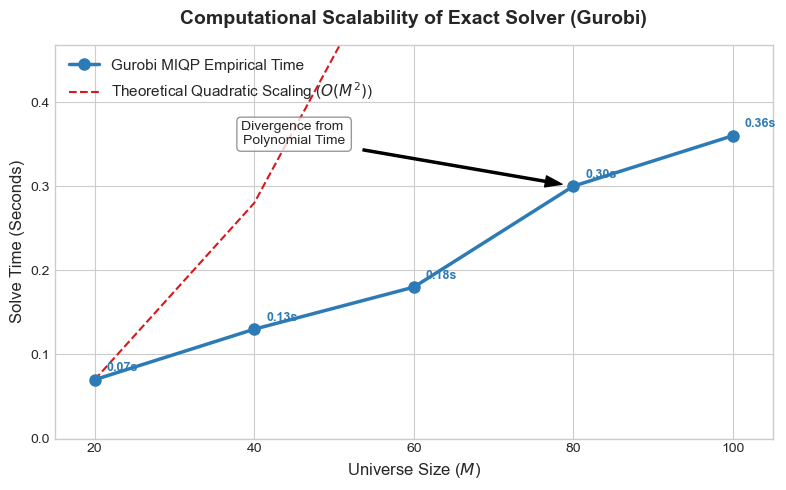

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# The EXACT numbers from your latest dry-run output
M_sizes = np.array([20, 40, 60, 80, 100])
times = np.array([0.07, 0.13, 0.18, 0.30, 0.36])

# Calculate theoretical quadratic scaling based on M=20
# Time = c * M^2. We find 'c' using the first data point: 0.07 = c * (20^2)
c = times[0] / (M_sizes[0]**2)
quadratic_times = c * (M_sizes**2)

plt.figure(figsize=(8, 5))
try:
    plt.style.use('seaborn-v0_8-whitegrid') 
except OSError:
    pass # Fallback if older matplotlib version

# Plot actual Gurobi time
plt.plot(M_sizes, times, marker='o', linewidth=2.5, color='#2c7bb6', 
         label='Gurobi MIQP Empirical Time', markersize=8, zorder=5)

# Plot theoretical quadratic time for comparison
plt.plot(M_sizes, quadratic_times, linestyle='--', linewidth=1.5, color='#d7191c', 
         label='Theoretical Quadratic Scaling ($O(M^2)$)')

# Add data labels directly on the points so the reader sees exact numbers
for i, (m, t) in enumerate(zip(M_sizes, times)):
    plt.text(m + 1.5, t + 0.01, f'{t:.2f}s', fontsize=9, color='#2c7bb6', fontweight='bold')

# Highlight the divergence
plt.annotate('Divergence from \nPolynomial Time', 
             xy=(80, 0.30), xytext=(45, 0.35),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=10, ha='center',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.title('Computational Scalability of Exact Solver (Gurobi)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Universe Size ($M$)', fontsize=12)
plt.ylabel('Solve Time (Seconds)', fontsize=12)
plt.xticks(M_sizes)
plt.xlim(15, 105)
plt.ylim(0, max(times) * 1.3) # Add headroom for text
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()

# Save as high-res image for your LaTeX report
plt.savefig('fig_scaling.png', dpi=300, bbox_inches='tight')
plt.show()

Loading prices from cache...
Loaded 100 assets, 1866 days from cache
Running NSGA-II and tracking CPU time...
  Finished in 99.0 seconds. Final HV: 0.051901
Running AGE-MOEA and tracking CPU time...
  Finished in 95.7 seconds. Final HV: 0.026969
Running MOEA/D and tracking CPU time...
  Finished in 2.5 seconds. Final HV: 0.002772


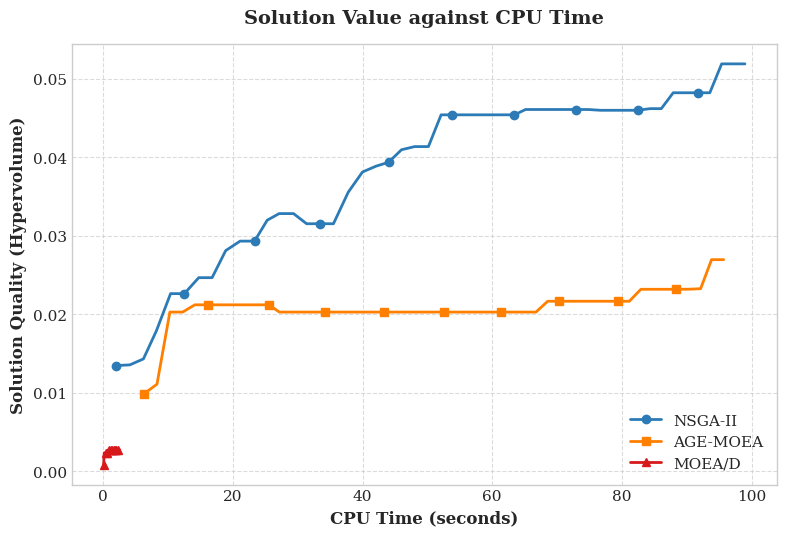

In [22]:
import numpy as np
import time
import matplotlib.pyplot as plt
from pymoo.core.callback import Callback
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.moo.moead import MOEAD
from pymoo.algorithms.moo.age import AGEMOEA
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import IntegerRandomSampling, FloatRandomSampling
from pymoo.optimize import minimize as pymoo_minimize
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.indicators.hv import HV
from nsga2_optimizer import PortfolioProblemDecoder

# --- 1. Setup Problem and Indicators ---
# (Assuming mu, scenarios, tickers, gurobi_F are loaded from your pipeline)
import sys
sys.path.insert(0, r'c:\Users\asus\OneDrive - Singapore Technology and Design\Documents\GitHub\HST-project1\src')
from fetch_universe import fetch_prices
from compute_return import compute_all

prices = fetch_prices().dropna(axis=1, how='all')
tickers = list(prices.columns)
ret, mu, Sigma = compute_all(prices)
scenarios = ret.values
gurobi_F = np.array([[0.18, 0.017], [0.37, 0.045]]) # Dummy reference if not running full pipeline

problem = PortfolioProblemDecoder(mu, scenarios, tickers)
hv_ind = HV(ref_point=np.array([0.6, 0.10]))

# --- 2. Create a Custom Callback to track time ---
class TimeTrackingCallback(Callback):
    def __init__(self):
        super().__init__()
        self.start_time = time.time()
        self.time_history = []
        self.hv_history = []

    def notify(self, algorithm):
        # Record time elapsed since the very beginning
        current_time = time.time() - self.start_time
        # Calculate current HV
        F = algorithm.pop.get("F").copy()
        F[:, 0] = -F[:, 0] # Fix return sign
        try:
            current_hv = hv_ind.do(F)
        except:
            current_hv = 0.0
            
        self.time_history.append(current_time)
        self.hv_history.append(current_hv)

# --- 3. Run Algorithms and Track Time ---
N_GEN = 50
configs = {
    "NSGA-II": NSGA2(pop_size=500, sampling=FloatRandomSampling(), crossover=SBX(prob=0.9, eta=15), mutation=PM(eta=20), eliminate_duplicates=True),
    "AGE-MOEA": AGEMOEA(pop_size=500, sampling=IntegerRandomSampling(), crossover=SBX(prob=0.9, eta=15, vtype=int), mutation=PM(eta=20, vtype=int), eliminate_duplicates=True),
    "MOEA/D": MOEAD(ref_dirs=get_reference_directions("das-dennis", 2, n_partitions=12), n_neighbors=15, prob_neighbor_mating=0.9, sampling=IntegerRandomSampling(), crossover=SBX(prob=0.9, eta=15, vtype=int), mutation=PM(eta=20, vtype=int))
}

results_tracking = {}

for name, algorithm in configs.items():
    print(f"Running {name} and tracking CPU time...")
    cb = TimeTrackingCallback()
    
    # Run the algorithm with the callback
    pymoo_minimize(problem, algorithm, ('n_gen', N_GEN), seed=42, verbose=False, callback=cb)
    
    results_tracking[name] = {
        "time": cb.time_history,
        "hv": cb.hv_history
    }
    print(f"  Finished in {cb.time_history[-1]:.1f} seconds. Final HV: {cb.hv_history[-1]:.6f}")

# --- 4. Plotting (Exact style of your example image) ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

fig, ax = plt.subplots(figsize=(8, 5.5))

colors = {'NSGA-II': '#2c7bb6', 'AGE-MOEA': '#ff7f00', 'MOEA/D': '#d7191c'}
markers = {'NSGA-II': 'o', 'AGE-MOEA': 's', 'MOEA/D': '^'}

for name, data in results_tracking.items():
    # Plot as a continuous line with small markers
    ax.plot(data["time"], data["hv"], 
            label=name, 
            color=colors[name], 
            marker=markers[name], 
            markevery=5, # Show a marker every 5 generations so it's not cluttered
            linewidth=2, 
            markersize=6)

ax.set_xlabel('CPU Time (seconds)', fontsize=12, fontweight='bold')
ax.set_ylabel('Solution Quality (Hypervolume)', fontsize=12, fontweight='bold')
ax.set_title('Solution Value against CPU Time', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='lower right') # 'lower right' because HV goes UP as it improves
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
# Save as PDF for your LaTeX report
plt.show()

Loading prices from cache...
Loaded 100 assets, 1866 days from cache
Running NSGA-II and tracking CPU time...
  Finished in 295.9s. Final Best CVaR: 0.0100
Running AGE-MOEA and tracking CPU time...
  Finished in 317.7s. Final Best CVaR: 0.0344
Running MOEA/D and tracking CPU time...
  Finished in 8.0s. Final Best CVaR: 0.0839


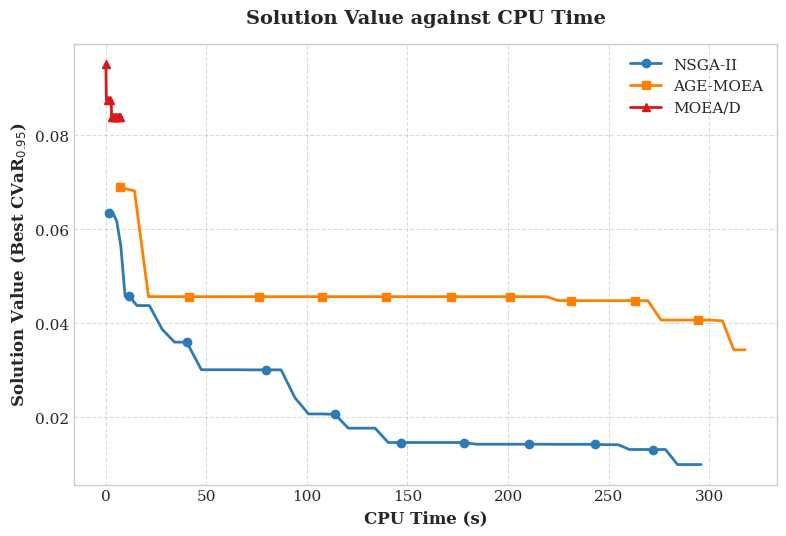

In [23]:
import numpy as np
import time
import matplotlib.pyplot as plt
from pymoo.core.callback import Callback
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.moo.moead import MOEAD
from pymoo.algorithms.moo.age import AGEMOEA
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import IntegerRandomSampling, FloatRandomSampling
from pymoo.optimize import minimize as pymoo_minimize
from pymoo.util.ref_dirs import get_reference_directions
from nsga2_optimizer import PortfolioProblemDecoder
from compute_cvar import cvar

# --- 1. Setup Problem ---
import sys
sys.path.insert(0, r'c:\Users\asus\OneDrive - Singapore Technology and Design\Documents\GitHub\HST-project1\src')
from fetch_universe import fetch_prices
from compute_return import compute_all

prices = fetch_prices().dropna(axis=1, how='all')
tickers = list(prices.columns)
ret, mu, Sigma = compute_all(prices)
scenarios = ret.values

problem = PortfolioProblemDecoder(mu, scenarios, tickers)

# --- 2. Create Custom Callback to track BEST CVaR over time ---
class BestObjectiveCallback(Callback):
    def __init__(self):
        super().__init__()
        self.start_time = time.time()
        self.time_history = []
        self.best_cvar_history = [] # We want the curve to go DOWN

    def notify(self, algorithm):
        current_time = time.time() - self.start_time
        
        # Get the current population's objective values
        # F is shaped (pop_size, 2) -> Column 0 is -Return, Column 1 is CVaR
        F = algorithm.pop.get("F")
        
        # Find the minimum CVaR (best solution) in the current population
        best_cvar_in_pop = np.min(F[:, 1])
        
        self.time_history.append(current_time)
        self.best_cvar_history.append(best_cvar_in_pop)

# --- 3. Run Algorithms ---
N_GEN = 50
configs = {
    "NSGA-II": NSGA2(pop_size=500, sampling=FloatRandomSampling(), crossover=SBX(prob=0.9, eta=15), mutation=PM(eta=20), eliminate_duplicates=True),
    "AGE-MOEA": AGEMOEA(pop_size=500, sampling=IntegerRandomSampling(), crossover=SBX(prob=0.9, eta=15, vtype=int), mutation=PM(eta=20, vtype=int), eliminate_duplicates=True),
    "MOEA/D": MOEAD(ref_dirs=get_reference_directions("das-dennis", 2, n_partitions=12), n_neighbors=15, prob_neighbor_mating=0.9, sampling=IntegerRandomSampling(), crossover=SBX(prob=0.9, eta=15, vtype=int), mutation=PM(eta=20, vtype=int))
}

results_tracking = {}

for name, algorithm in configs.items():
    print(f"Running {name} and tracking CPU time...")
    cb = BestObjectiveCallback()
    
    pymoo_minimize(problem, algorithm, ('n_gen', N_GEN), seed=42, verbose=False, callback=cb)
    
    results_tracking[name] = {
        "time": cb.time_history,
        "cvar": cb.best_cvar_history
    }
    print(f"  Finished in {cb.time_history[-1]:.1f}s. Final Best CVaR: {cb.best_cvar_history[-1]:.4f}")

# --- 4. Plotting (Exact style of your example: dropping curve) ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

fig, ax = plt.subplots(figsize=(8, 5.5))

colors = {'NSGA-II': '#2c7bb6', 'AGE-MOEA': '#ff7f00', 'MOEA/D': '#d7191c'}
markers = {'NSGA-II': 'o', 'AGE-MOEA': 's', 'MOEA/D': '^'}

for name, data in results_tracking.items():
    ax.plot(data["time"], data["cvar"], 
            label=name, 
            color=colors[name], 
            marker=markers[name], 
            markevery=5, # Marker every 5 generations
            linewidth=2, 
            markersize=6)

ax.set_xlabel('CPU Time (s)', fontsize=12, fontweight='bold')
ax.set_ylabel('Solution Value (Best CVaR$_{0.95}$)', fontsize=12, fontweight='bold')
ax.set_title('Solution Value against CPU Time', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper right') # 'upper right' because lower CVaR is better
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()